# Vinos con KNN

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"

df = pd.read_csv(url, sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Filas y columnas:", df.shape)

print("\nColumnas:", df.columns.tolist())

Filas y columnas: (1599, 12)

Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


Este dataset tiene una columna llamada quality con valores del 1 al 10, necesito convertirla en 3 categorías para que KNN las clasifique en :

0 = baja calidad (=< quality 5)

1 = Calidad media (= 6)

2 = Calidad alta ( >= 7)

In [4]:
def convertir_calidad(q):
    if q <= 5:
        return 0   
    elif q == 6:
        return 1   
    else:
        return 2 

In [5]:
# Aplicamos la función a toda la columna 'quality' y creamos la nueva columna 'label'

df["label"] = df["quality"].apply(convertir_calidad)

print(df["label"].value_counts().sort_index())

label
0    744
1    638
2    217
Name: count, dtype: int64


Separaos variable independiente (X) y variable objetio (Y)

In [6]:
X = df.drop(columns=["quality", "label"])

y = df["label"]

print("Tamaño de X (características):", X.shape)
print("Tamaño de y (etiquetas):       ", y.shape)

Tamaño de X (características): (1599, 11)
Tamaño de y (etiquetas):        (1599,)


Divido entrenamiento y prueba 

In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Muestras de entrenamiento:", X_train.shape[0])
print("Muestras de prueba:       ", X_test.shape[0])

Muestras de entrenamiento: 1279
Muestras de prueba:        320


Vamos a escalar los datos

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


Entrenamos el modelo con K = 5 vecinos


In [11]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Evaluo el modelo con las metricas:

- accuracy_score
- confusion_matrix
- classification_report

In [12]:
# lista vacía donde guardaremos la accuracy de cada k

accuracies = []

# Recorremos los valores de k del 1 al 20
for k in range(1, 21):
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_scaled, y_train)
    pred_k = modelo_k.predict(X_test_scaled)
    acc_k = accuracy_score(y_test, pred_k)
    accuracies.append(acc_k)

for i, acc in enumerate(accuracies, start=1):
    print(f"k={i:2d} → accuracy: {acc:.2%}")

k= 1 → accuracy: 65.94%
k= 2 → accuracy: 58.75%
k= 3 → accuracy: 55.31%
k= 4 → accuracy: 57.19%
k= 5 → accuracy: 58.44%
k= 6 → accuracy: 59.38%
k= 7 → accuracy: 58.75%
k= 8 → accuracy: 59.06%
k= 9 → accuracy: 59.69%
k=10 → accuracy: 60.94%
k=11 → accuracy: 60.00%
k=12 → accuracy: 60.62%
k=13 → accuracy: 60.94%
k=14 → accuracy: 60.62%
k=15 → accuracy: 60.31%
k=16 → accuracy: 61.56%
k=17 → accuracy: 59.38%
k=18 → accuracy: 60.00%
k=19 → accuracy: 57.19%
k=20 → accuracy: 58.44%


el mejor es el K = 16 el modelo se estabiliza y mejora gradualmente.

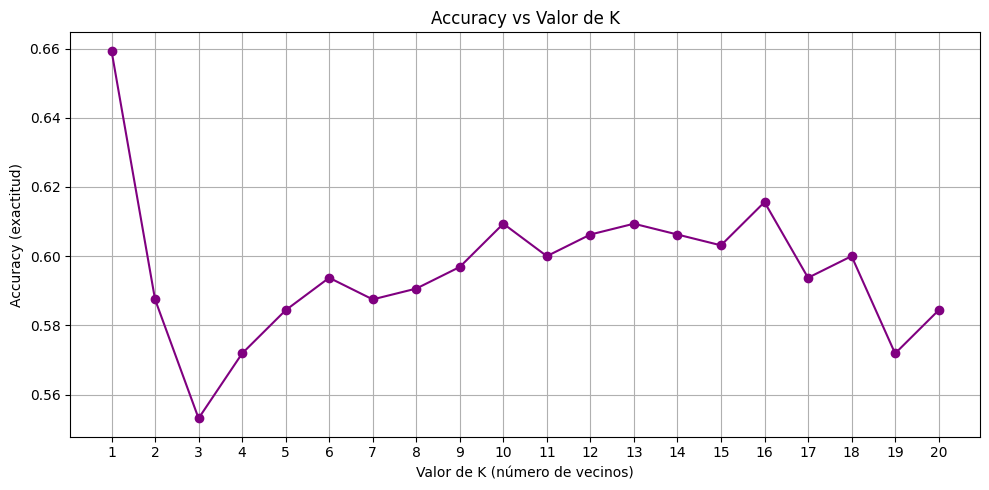


Mejor k: 1 con accuracy de 65.94%


In [14]:
# Graficamos accuracy vs k para ver cuál es el mejor valor visualmente
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), accuracies, marker="o", color="purple")
plt.title("Accuracy vs Valor de K")
plt.xlabel("Valor de K (número de vecinos)")
plt.ylabel("Accuracy (exactitud)")
plt.xticks(range(1, 21))   
plt.grid(True)              
plt.tight_layout()
plt.show()

mejor_k = accuracies.index(max(accuracies)) + 1   # +1 porque la lista empieza en índice 0
print(f"\nMejor k: {mejor_k} con accuracy de {max(accuracies):.2%}")